# John Snow's Cholera Outbreak Map

## Introduction:

Cholera is an intestinal disease caused by the bacterium Vibrio cholerae, which can be spread by consuming contaminated food and water. During the 1800s, there was a massive cholera outbreak in London, and many people died because of it.

John Snow, a physician at the time, conducted investigations to trace and locate the source of the Cholera outbreak. By researching and doing interviews with the locals, he was able to create a map where cases of Cholera were found. 

As a result, he discovered that all these cases had a common source, which was a water pump on Broad Street. By removing the handle of the pump, there was an immediate decrease in cases of the disease. 

Let's first examine Snow's original Cholera outbreak map, and then we'll look at three iterations of it as well!

## Original Map of the Outbreak Drawn by Snow:


Here is the original design of the Cholera map from Snow!


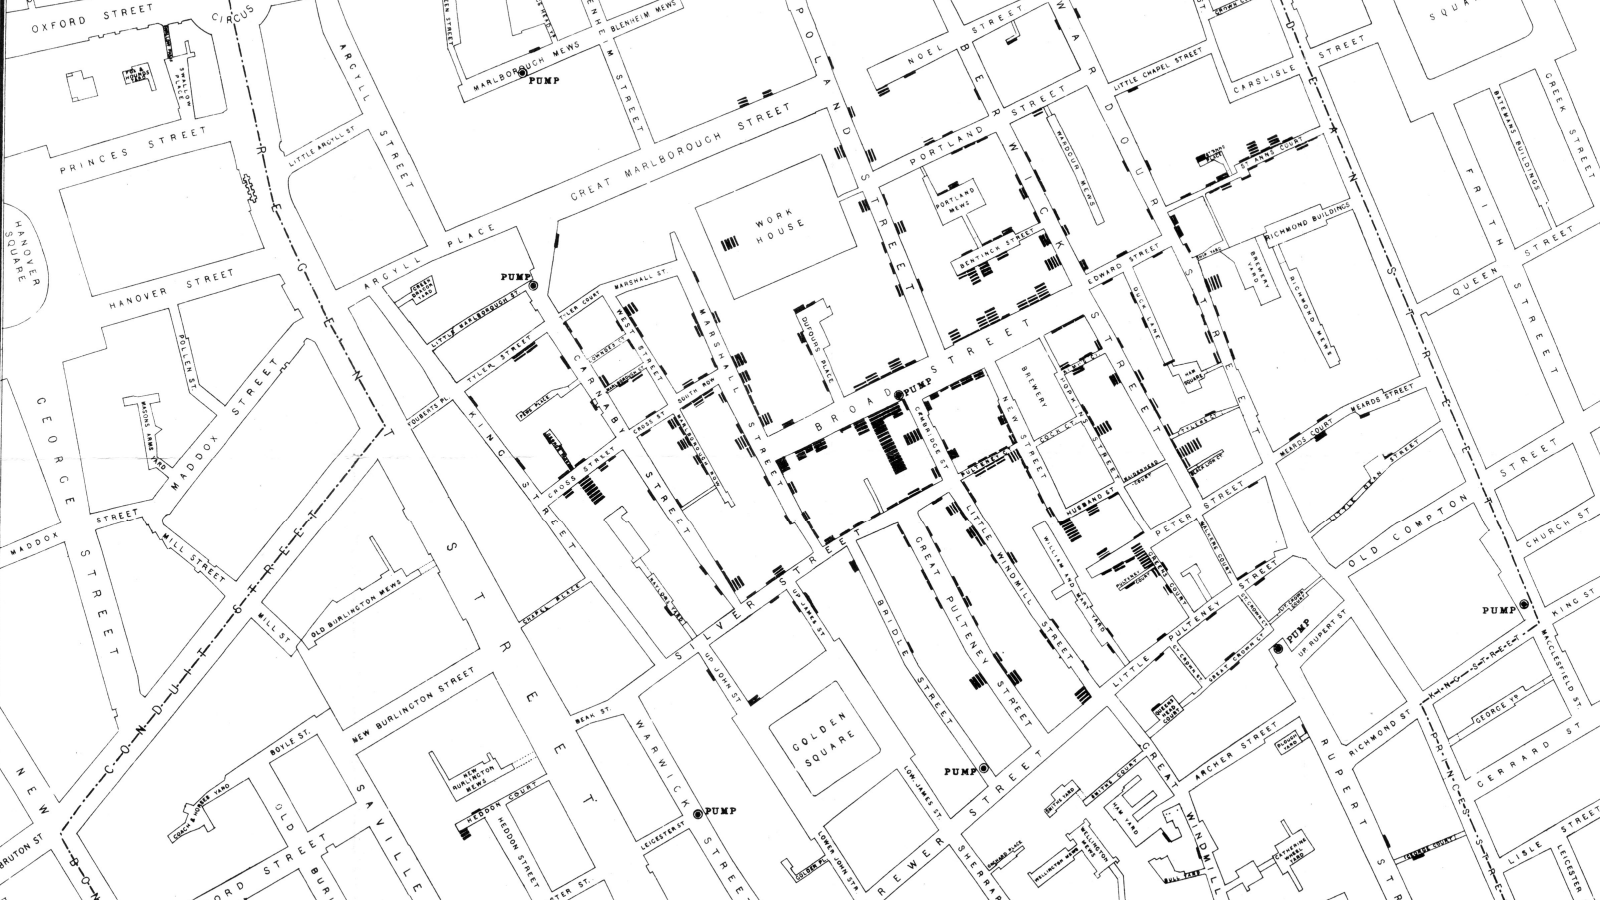

In [1]:
# Import Image and display functions from IPython.display to show images
from IPython.display import Image, display

# Display Output
print("\nHere is the original design of the Cholera map from Snow!")
Image("snowmap.png", width = 700)

## Iteration One: Longitude–Latitude Graph of the Outbreak

Let us look at the locations of the water pumps and the death cases by using a longitude and latitude graph. By doing so, we could see which water pump had more cases of Cholera, and which didn't. 

Firstly, let us load the pump.csv file and then graph the locations of the water pumps by using a longitude and latitude graph.

In [2]:
# Import the pandas library and read the pumps.csv file
import pandas as pd

pump_data = pd.read_csv("pumps.csv")

# Display data
pump_data

,pump_name,latitude,longitude
0,Broad St.,51.513341,-0.136668
1,Crown Chapel,51.513876,-0.139586
2,Gt Marlborough,51.514906,-0.139671
3,Dean St.,51.512354,-0.131630
4,So Soho,51.512139,-0.133594
5,Briddle St.,51.511542,-0.135919
6,Coventry St.,51.510019,-0.133962
7,Warwick,51.511295,-0.138199


Now let's use Matplotlib to create a scatter plot showing the geographic locations of water pumps based on their longitude and latitude coordinates from the pump_data dataset.

Each pump is represented by a circle marker, and its name is labeled beside its location on the plot.

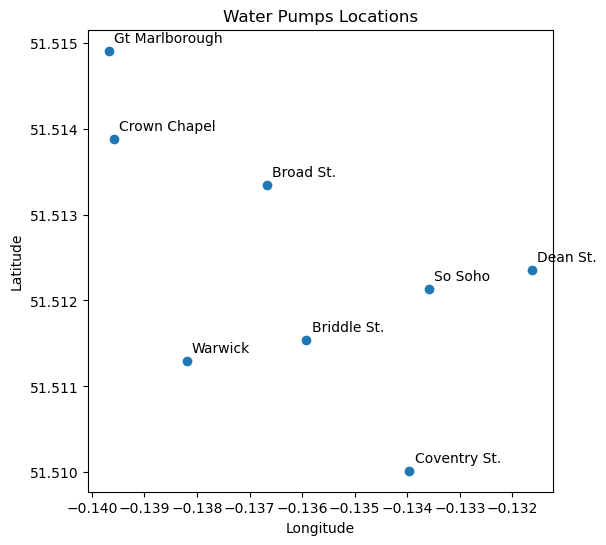

In [3]:
# Import matplotlib.pyplot module to build plots
import matplotlib.pyplot as plt

# Building a 6x6 inch square figure for the scatter plot
scatter_plot1 = plt.figure(figsize = (6,6))

# Plot the longitude and latitude of the pumps as circular markers
plt.scatter(pump_data['longitude'], pump_data['latitude'], marker = 'o')

# Looping through each row, to label each pump on the plot
for _, i in pump_data.iterrows():
    # Adding text beside the coordinate for labelling
    plt.text(i['longitude'] + 0.0001, i['latitude'] + 0.0001, i['pump_name'], fontsize = 10)

# Adding title, xlabel, ylabel
plt.title("Water Pumps Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Now since the water pump locations are plotted, let's plot the death locations on the same graph. First, let's load the deaths.csv file, and then plot them using matplotlib.

In [4]:
# Import the pandas library and read the deaths.csv file
import pandas as pd

death_data = pd.read_csv("deaths.csv")

# Display data (only the top 5 rows are shown since the data is too long)
death_data.head()

,death_count,latitude,longitude
0,1,51.513418,-0.137930
1,1,51.513418,-0.137930
2,1,51.513418,-0.137930
3,1,51.513361,-0.137883
4,1,51.513361,-0.137883


Now let's use Matplotlib to show the geographic locations of the deaths that had taken place based on their longitude and latitude coordinates from the death_data dataset. Each death is shown as a small red circle dot.

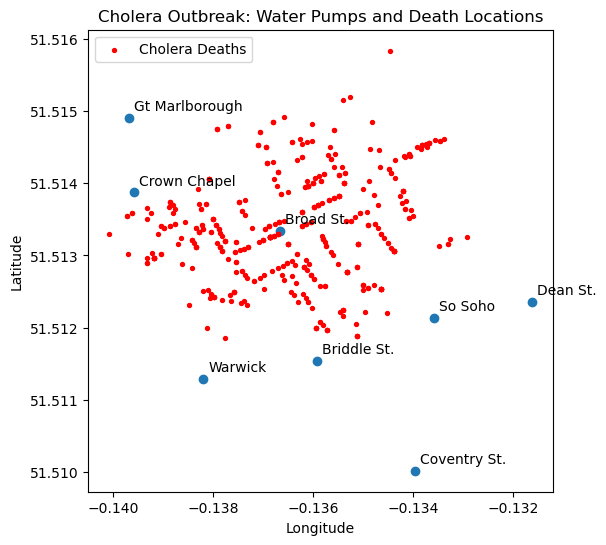

In [5]:
# Building a 6x6 inch square figure for the scatter plot
scatter_plot2 = plt.figure(figsize = (6, 6))

plt.scatter(pump_data['longitude'], pump_data['latitude'], marker = 'o')

for _, i in pump_data.iterrows():
    plt.text(i['longitude'] + 0.0001, i['latitude'] + 0.0001, i['pump_name'], fontsize = 10)

# Plot cholera death locations as small red dots
plt.scatter(death_data['longitude'], death_data['latitude'], color = 'red', s = 8, label = 'Cholera Deaths')

# Adding title, xlabel, ylabel
plt.title("Cholera Outbreak: Water Pumps and Death Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()

By looking at the location of the deaths and water pumps on the graph, the most noticeable feature is that there is a dense cluster of red dots surrounding the “Broad St.” water pump. This would suggest that there are a lot of Cholera deaths happening near this pump, and this led Snow to hypothesize and eventually realize that the contaminated water from this pump was the source of the outbreak.

Also, other pumps like “Dean St.”, “Coventry St.”, and “Warwick” show significantly fewer nearby deaths, indicating that residents closer to those pumps were less affected. This strengthened Snow’s argument that cholera was actually waterborne, not airborne (as many believed at the time).

## Iteration Two: Utilizing 'ipyleaflet' to Showcase the Locations of Death on the Map

Even though we looked at a graphical longitudinal and latitudinal map of the Cholera outbreak, let us look at it geographically by using ipyleaflet. We will first look at the map of Soho, then add the locations of the water pumps, and then add the locations of the deaths that occurred.

Before building the maps, I have to install ipyleaflet and ipywidgets in my Jupyter Notebook environment, so that the maps work. (Please run this cell if you do not have ipyleaflet installed, and then run each cell afterwards in sequence).

In [6]:
!pip install ipyleaflet ipywidgets

Firstly we will show the map of Soho - by using pandas and ipyleaflet.

In [7]:
# Import the pandas library and read the pumps.csv file
import pandas as pd
# Import map and marker tools from ipyleaflet
from ipyleaflet import Map, Marker, MarkerCluster, LayersControl

pumps = pd.read_csv("pumps.csv")

# Calculate the average latitude and longitude to center the map
center = (pumps["latitude"].mean(), pumps["longitude"].mean())

# Create a map centered on the average location with zoom level 16
map = Map(center = center, zoom = 16)
map

Map(center=[51.512434, -0.136153625], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_titl…

Next let's show the locations of the water pumps.

In [11]:
import pandas as pd
from ipyleaflet import Map, Marker, MarkerCluster, LayersControl

pumps = pd.read_csv("pumps.csv")

center = (pumps["latitude"].mean(), pumps["longitude"].mean())
map = Map(center = center, zoom = 16)

# Create a marker for each pump location
markers = []
for _, i in pumps.iterrows():
    m = Marker(location = (i.latitude, i.longitude))
    # Add the marker to the list
    markers.append(m)

# Group all markers into a cluster to manage multiple points efficiently
cluster = MarkerCluster(markers = markers)

# Add the cluster of markers to the map
map.add_layer(cluster)

# Add a layer control to toggle map features (e.g., markers, layers)
map.add_control(LayersControl())
map 

Map(center=[51.512434, -0.136153625], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_titl…

Next let's add the locations that the deaths had occured.

In [9]:
# Import the pandas library and read the pumps.csv and the deaths.csv files
import pandas as pd
from ipyleaflet import Map, Marker, MarkerCluster, LayersControl, CircleMarker, LayerGroup

pumps = pd.read_csv("pumps.csv")
deaths = pd.read_csv("deaths.csv")

center = (pumps["latitude"].mean(), pumps["longitude"].mean())
map = Map(center = center, zoom = 16)

markers = []
for _, i in pumps.iterrows():
    m = Marker(location = (i.latitude, i.longitude))
    markers.append(m)
    
cluster = MarkerCluster(markers = markers)

# Name the layer for display in the map legend
cluster.name = "Water Pumps"

# Drop rows that have missing coordinates
deaths = deaths.dropna(subset = ["latitude", "longitude"])

# Create an empty list to store death circle markers
death_circles = []

# Loop through each row in the deaths dataset
for _, i in deaths.iterrows():
    # Add a small red circle for each death location
    death_circles.append(CircleMarker(location = (i["latitude"], i["longitude"]), radius = 3, color = "red", fill_color = "red", fill_opacity = 0.8))

# Group all death circle markers into one layer
death_layer = LayerGroup(layers = death_circles)

# Name the layer for display in the map legend
death_layer.name = "Deaths (Red Dots)"

# Add the death layer to the map
map.add_layer(death_layer)

map.add_layer(cluster)
map.add_control(LayersControl())
map


Map(center=[51.512434, -0.136153625], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_titl…

Similarly to the graphical map, there seem to be more cases of Cholera around “Broad St.” water pump. The difference between the two maps is that this map shows the geographical regions in which most cases of Cholera were prevalent. For example, you can see that most deaths occurred along Broad Street, Poland Street, and Marshall Street, illustrating how the disease spread within specific streets rather than uniformly.

## Iteration Three: Utilizing 'ipyleaflet' to Create a 'Death' Heat Map

In our final iteration, let's create a heatmap illustrating the deaths that happened near the “Broad St.” water pump.

In [10]:
import pandas as pd
from ipyleaflet import Map, Marker, MarkerCluster, LayersControl, AwesomeIcon, Heatmap

pumps = pd.read_csv("pumps.csv")
deaths = pd.read_csv("deaths.csv").dropna(subset = ["latitude","longitude"])

center = (pumps["latitude"].mean(), pumps["longitude"].mean())
map = Map(center = center, zoom = 16)

markers = []
for _, i in pumps.iterrows():
    m = Marker(location = (i.latitude, i.longitude))
    markers.append(m)

cluster = MarkerCluster(markers = markers)
cluster.name = "Water Pumps"

# Extract latitude and longitude values as a list of coordinates
death_points = deaths[["latitude","longitude"]].values.tolist()

# Create a heatmap layer to show death density (hotter areas = more deaths)
heat = Heatmap(locations = death_points, radius = 18, blur = 15, name = "Deaths (Heatmap)")

# Add the heatmap layer to the map
map.add_layer(heat)

map.add_layer(cluster)
map.add_control(LayersControl())
map


Map(center=[51.512434, -0.136153625], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_titl…

Similar to previous maps, the majority of the deaths that happened were around the “Broad St.” water pump. If you look at the other water pumps on “Dean St.” and “Coventry St.", they were mostly unaffected, illustrating that there is a correlation between being close to the “Broad St.” water pump and the number of deaths.